# Orbital Propagation (Keplerian Model)

## Imports

In [8]:
import numpy as np
import matplotlib.pyplot as plt


## Physical constants

In [9]:
MU = 398600.4418  # Earth's gravitational parameter [km^3/s^2]
OMEGA_EARTH = 7.2921159e-5  # Earth rotation rate [rad/s]

## Mean motion to semi-major axis


In [10]:
def mean_motion_to_semi_major_axis(n):
    """
    Convert mean motion (rev/day) to semi-major axis (km)
    """
    n_rad = n * 2 * np.pi / 86400  # rad/s
    a = (MU / n_rad**2)**(1/3)
    return a

## Solve Kepler’s Equation

In [11]:
def solve_kepler(M, e, tol=1e-8):
    """
    Solve Kepler's equation using Newton-Raphson
    """
    E = M
    for _ in range(100):
        f = E - e*np.sin(E) - M
        f_prime = 1 - e*np.cos(E)
        E = E - f / f_prime
        if abs(f) < tol:
            break
    return E

## Rotation Matrix

In [12]:
def rotation_matrix(i, raan, argp):
    """
    Compute rotation matrix from perifocal to ECI frame
    """
    cos_O = np.cos(raan)
    sin_O = np.sin(raan)
    cos_i = np.cos(i)
    sin_i = np.sin(i)
    cos_w = np.cos(argp)
    sin_w = np.sin(argp)

    return np.array([
        [cos_O*cos_w - sin_O*sin_w*cos_i, -cos_O*sin_w - sin_O*cos_w*cos_i, sin_O*sin_i],
        [sin_O*cos_w + cos_O*sin_w*cos_i, -sin_O*sin_w + cos_O*cos_w*cos_i, -cos_O*sin_i],
        [sin_w*sin_i,                      cos_w*sin_i,                      cos_i]
    ])

## Satellite propagation function

In [13]:
def propagate_satellite(sat, duration_minutes=90, step_seconds=60):
    """
    Propagate satellite position using Keplerian model
    Returns latitude and longitude arrays
    """

    l2 = sat["l2"]

    # Extract orbital elements from TLE line 2
    i = np.radians(float(l2[8:16]))              # inclination
    raan = np.radians(float(l2[17:25]))          # RAAN
    e = float("0." + l2[26:33].strip())          # eccentricity
    argp = np.radians(float(l2[34:42]))          # argument of perigee
    M0 = np.radians(float(l2[43:51]))            # mean anomaly
    n = float(l2[52:63])                         # mean motion (rev/day)

    # Semi-major axis
    a = mean_motion_to_semi_major_axis(n)

    # Rotation matrix
    R = rotation_matrix(i, raan, argp)

    lats = []
    lons = []

    for t in range(0, duration_minutes * 60, step_seconds):

        # Mean anomaly (normalized)
        M = (M0 + (n * 2*np.pi / 86400) * t) % (2*np.pi)

        # Solve Kepler
        E = solve_kepler(M, e)

        # Position in perifocal frame
        x_pf = a * (np.cos(E) - e)
        y_pf = a * np.sqrt(1 - e**2) * np.sin(E)
        z_pf = 0

        r_pf = np.array([x_pf, y_pf, z_pf])

        # Convert to ECI
        r_eci = R @ r_pf
        X, Y, Z = r_eci

        # Earth rotation (ECI → ECEF)
        theta = OMEGA_EARTH * t

        X_ecef = X * np.cos(theta) + Y * np.sin(theta)
        Y_ecef = -X * np.sin(theta) + Y * np.cos(theta)
        Z_ecef = Z

        # Convert to lat/lon
        r = np.sqrt(X_ecef**2 + Y_ecef**2 + Z_ecef**2)
        lat = np.degrees(np.arcsin(Z_ecef / r))
        lon = np.degrees(np.arctan2(Y_ecef, X_ecef))

        lats.append(lat)
        lons.append(lon)

    return lats, lons

## Test with one satellite

In [18]:
sats = [
    {
        "name": "ISS",
        "l2": "2 25544  51.6435  21.5176 0007417  83.9843  44.6062 15.49515369399929"
    },
    {
        "name": "NOAA 15",
        "l2": "2 25338  98.7350  72.1234 0012000 120.0000 240.0000 14.25900000"
    },
    {
        "name": "Hubble",
        "l2": "2 20580  28.4697 130.5360 0002946  54.2803 305.8534 15.09200000"
    }
]

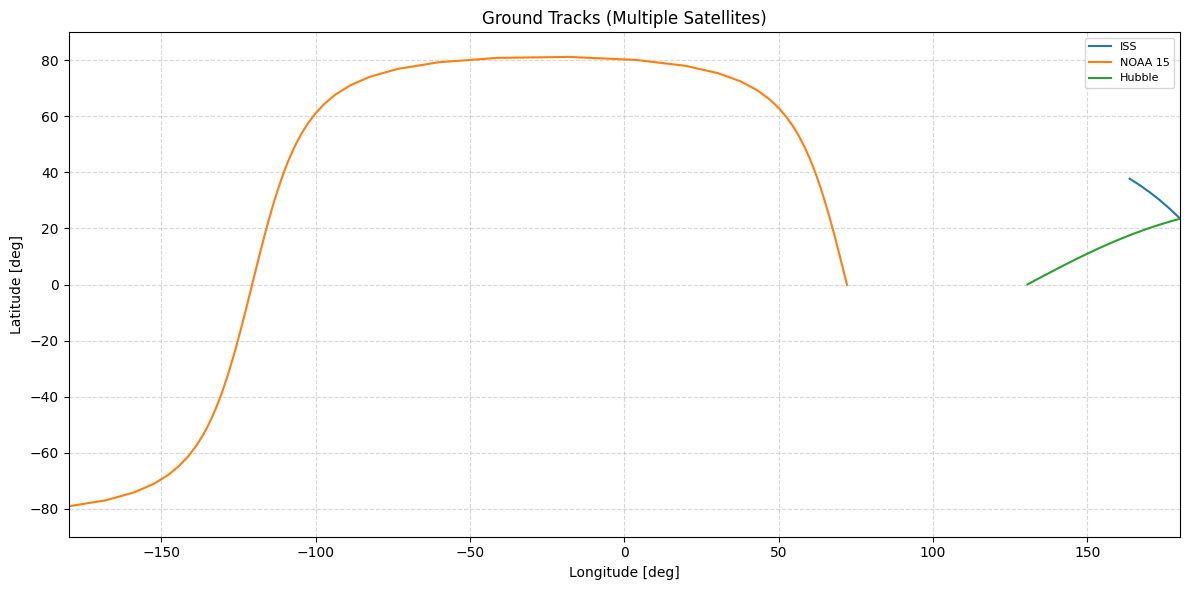

In [19]:
plt.figure(figsize=(12,6))

for sat in sats[:5]:
    lats, lons = propagate_satellite(sat)

    # Fix longitude jumps (important for visualization)
    lons = np.unwrap(np.radians(lons))
    lons = np.degrees(lons)

    plt.plot(lons, lats, label=sat["name"], linewidth=1.5)

# Earth limits
plt.xlim(-180, 180)
plt.ylim(-90, 90)

plt.xlabel("Longitude [deg]")
plt.ylabel("Latitude [deg]")
plt.title("Ground Tracks (Multiple Satellites)")

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## Plot ground track

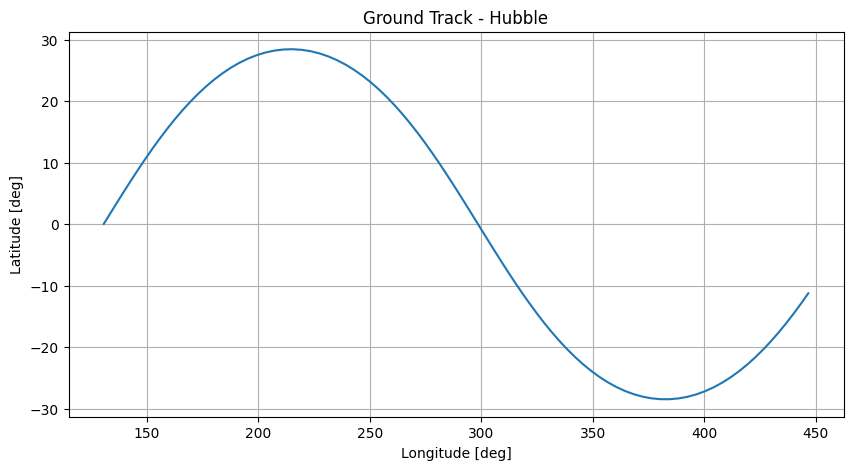

In [20]:
plt.figure(figsize=(10,5))
plt.plot(lons, lats)
plt.xlabel("Longitude [deg]")
plt.ylabel("Latitude [deg]")
plt.title(f"Ground Track - {sat['name']}")
plt.grid()
plt.show()

## Multiple Satellites

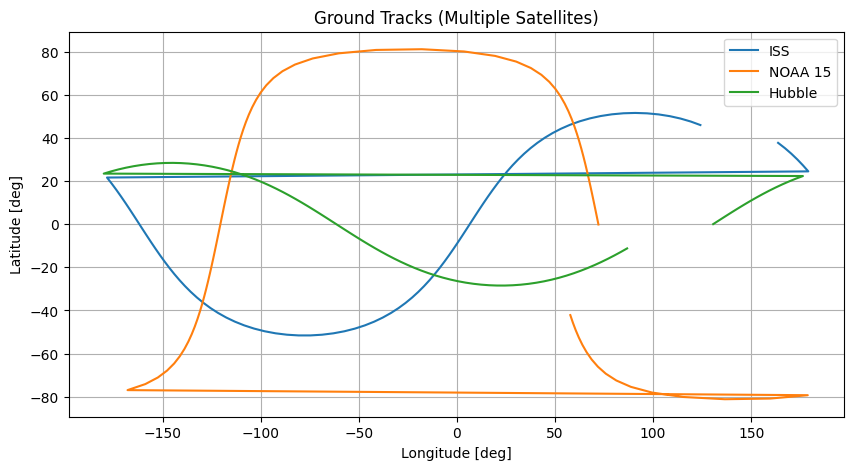

In [21]:
plt.figure(figsize=(10,5))

for sat in sats[:5]:
    lats, lons = propagate_satellite(sat)
    plt.plot(lons, lats, label=sat["name"])

plt.xlabel("Longitude [deg]")
plt.ylabel("Latitude [deg]")
plt.title("Ground Tracks (Multiple Satellites)")
plt.legend()
plt.grid()
plt.show()